Granules encontrados: 97
00  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2002-06-22T14:14:08.906000Z  id=AST_07XT_00406222002141408_20250223101850
01  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2002-08-09T14:14:07.638000Z  id=AST_07XT_00408092002141407_20250225073943
02  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2002-08-18T14:08:12.869000Z  id=AST_07XT_00408182002140812_20250225151120
03  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2003-07-27T14:11:44.407000Z  id=AST_07XT_00407272003141144_20250313021918
04  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2004-07-06T14:06:12.911000Z  id=AST_07XT_00407062004140612_20250329043322
05  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2004-07-06T14:06:21.766000Z  id=AST_07XT_00407062004140621_20250329043258
06  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2004-07-29T14:12:20.641000Z  id=AST_07XT_00407292004141220_20250330042033
07  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2005-08-01T14:12:02.298000Z  id=AST_07XT_00408012

QUEUEING TASKS | :   0%|          | 0/13 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/13 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/13 [00:00<?, ?it/s]

/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/rioxarray/rioxarray.py:700: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/rioxarray/rioxarray.py:700: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


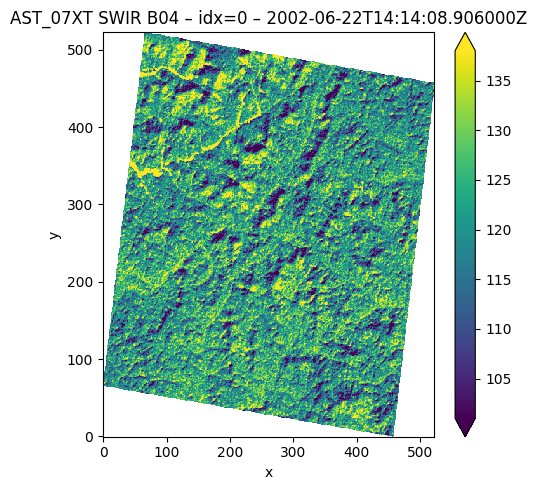

In [94]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import re
import tempfile
from pathlib import Path

import earthaccess as ea
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rxr
from shapely.geometry import shape

# ------------------------------------------------------------
# METADADOS: nuvem
# ------------------------------------------------------------

def _extract_numbers_from_attr(attr):
    vals = attr.get("Values") or []
    text = " ".join(str(v) for v in vals)
    nums_str = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)
    if not nums_str:
        return None
    return [float(s) for s in nums_str]


def get_cloud_from_umm(granule):
    """
    Retorna (cloud_mean, cloud_list, attr_name) a partir de AdditionalAttributes.
    Se não achar info de nuvem, retorna (None, None, None).
    """
    umm = granule["umm"]
    attrs = umm.get("AdditionalAttributes", [])
    best = None

    for attr in attrs:
        name = (attr.get("Name") or "").lower()
        if "cloud" not in name:
            continue

        nums = _extract_numbers_from_attr(attr)
        if not nums:
            continue

        mean_val = float(np.mean(nums))

        if best is None:
            best = (mean_val, nums, name)
        else:
            # preferência para algo contendo "cloud_coverage_data"
            if "cloud_coverage_data" in name and "cloud_coverage_data" not in best[2]:
                best = (mean_val, nums, name)
            elif mean_val < best[0]:
                best = (mean_val, nums, name)

    if best is None:
        return None, None, None
    return best


def sort_by_cloud(results):
    """
    results -> lista [(cloud_mean, granule, attr_name)] ordenada por nuvem crescente.
    """
    tmp = []
    for g in results:
        cc_mean, cc_list, attr_name = get_cloud_from_umm(g)
        if cc_mean is None:
            cc_mean = 999.0
            attr_name = None
        tmp.append((cc_mean, g, attr_name))
    tmp_sorted = sorted(tmp, key=lambda t: t[0])
    return tmp_sorted


# ------------------------------------------------------------
# DOWNLOAD + CLIP SWIR B04
# ------------------------------------------------------------

def download_swir_b04(granule, out_dir=None):
    out_dir = Path(out_dir or tempfile.mkdtemp(prefix="AST_07XT_"))
    files = ea.download([granule], local_path=out_dir)
    b4_list = [Path(f) for f in files if "SRF_SWIR_B04" in str(f)]
    if not b4_list:
        raise RuntimeError("Nenhum arquivo SRF_SWIR_B04* encontrado nesse granule.")
    return b4_list[0]


def clip_to_geom(tif_path, geom_geojson):
    g = shape(geom_geojson)
    gdf = gpd.GeoDataFrame(geometry=[g], crs="EPSG:4326")
    da = rxr.open_rasterio(tif_path, masked=True)
    gdf_proj = gdf.to_crs(da.rio.crs)
    da_clip = da.rio.clip(
        gdf_proj.geometry,
        gdf_proj.crs,
        drop=True,
        all_touched=True,
    )
    return da_clip


def _get_granule_date_str(granule):
    umm = granule["umm"]
    te = umm.get("TemporalExtent") or umm.get("TemporalCoverage") or {}
    date = te.get("SingleDateTime")
    if not date:
        rd = te.get("RangeDateTime") or {}
        date = rd.get("BeginningDateTime") or "n/a"
    return date


def preview_swir_b04(granule, geom_geojson, out_dir=None, idx=None):
    tif_path = download_swir_b04(granule, out_dir=out_dir)
    da_clip = clip_to_geom(tif_path, geom_geojson)

    arr = da_clip.squeeze().values
    vmin, vmax = np.nanpercentile(arr, [2, 98])

    fig, ax = plt.subplots(figsize=(5, 5))
    da_clip.squeeze().plot.imshow(ax=ax, vmin=vmin, vmax=vmax)

    date_str = _get_granule_date_str(granule)
    if idx is not None:
        title = f"AST_07XT SWIR B04 – idx={idx} – {date_str}"
    else:
        title = f"AST_07XT SWIR B04 – {date_str}"

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return da_clip, tif_path


# ------------------------------------------------------------
# BUSCA CMR + ORDENAÇÃO POR NUVEM PARA UMA FOLHA
# ------------------------------------------------------------

def search_ast07xt_for_geom(geom_geojson, temporal=("2000-01-01", "2015-01-01")):
    g = shape(geom_geojson)
    minx, miny, maxx, maxy = g.bounds

    ea.login()

    results = ea.search_data(
        short_name="AST_07XT",
        version="004",
        bounding_box=(minx, miny, maxx, maxy),
        temporal=temporal,
    )
    sorted_results = sort_by_cloud(results)
    return results, sorted_results


# ------------------------------------------------------------
# EXEMPLO DE USO NO IPYTHON
# ------------------------------------------------------------
if __name__ == "__main__":
    from db_conn import get_folha_geom_geojson as folha

    folha_id = "SB21_ZA_II2_NW"
    geom = folha(folha_id)

    results, sorted_results = search_ast07xt_for_geom(geom)
    print(f"Granules encontrados: {len(results)}")

    # listar os 10 melhores por nuvem
    N = min(10, len(sorted_results))
    for rank, (cc, gran, attr_name) in enumerate(sorted_results[:N]):
        date = _get_granule_date_str(gran)
        gran_id = gran["umm"].get("GranuleUR", "n/a")
        print(f"{rank:02d}  cloud≈{cc:5.1f}%  attr={attr_name}  date={date}  id={gran_id}")

    # preview da melhor cena (rank 0)
    best_cc, best_gran, best_attr = sorted_results[0]
    print("\nMelhor granule por nuvem:")
    print("cloud_mean≈", best_cc, "attr=", best_attr)
    da_clip, local_tif = preview_swir_b04(best_gran, geom, idx=0)


Granules AST_07XT encontrados: 97
00  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2002-06-22T14:14:08.906000Z  id=AST_07XT_00406222002141408_20250223101850
01  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2002-08-09T14:14:07.638000Z  id=AST_07XT_00408092002141407_20250225073943
02  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2002-08-18T14:08:12.869000Z  id=AST_07XT_00408182002140812_20250225151120
03  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2003-07-27T14:11:44.407000Z  id=AST_07XT_00407272003141144_20250313021918
04  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2004-07-06T14:06:12.911000Z  id=AST_07XT_00407062004140612_20250329043322
05  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2004-07-06T14:06:21.766000Z  id=AST_07XT_00407062004140621_20250329043258
06  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2004-07-29T14:12:20.641000Z  id=AST_07XT_00407292004141220_20250330042033
07  cloud≈  0.0%  attr=quadrantcloudcoverage  date=2005-08-01T14:12:02.298000Z  id=AST_07XT

QUEUEING TASKS | :   0%|          | 0/13 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/13 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/13 [00:00<?, ?it/s]

/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/rioxarray/rioxarray.py:700: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/rioxarray/rioxarray.py:700: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


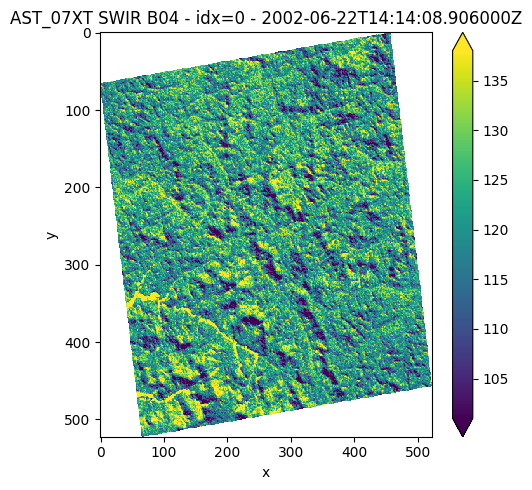

DEBUG:pystac_client.stac_api_io:GET https://planetarycomputer.microsoft.com/api/stac/v1 Headers: {'User-Agent': 'python-requests/2.32.5', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive'}
DEBUG:pystac_client.stac_api_io:GET https://planetarycomputer.microsoft.com/api/stac/v1/ Headers: {'User-Agent': 'python-requests/2.32.5', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive'}
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
DEBUG:pystac_client.stac_api_io:POST https://planetarycomputer.microsoft.com/api/stac/v1/search Headers: {'User-Agent': 'python-requests/2.32.5', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive', 'Content-Length': '290', 'Content-Type': 'application/json'} Payload: {"limit": 100, "datetime": "2017-01-01T00:00:00Z/2025-12-31T23:59:59Z", "c


Itens Sentinel-2 L2A encontrados: 349
00  cloud≈  0.0%  datetime=2023-07-23T14:07:09.024000Z  id=S2B_MSIL2A_20230723T140709_R110_T21MWP_20241014T122425
01  cloud≈  0.0%  datetime=2025-07-07T14:11:11.025000Z  id=S2C_MSIL2A_20250707T141111_R110_T21MWP_20250707T172719
02  cloud≈  0.0%  datetime=2024-06-07T14:07:09.024000Z  id=S2B_MSIL2A_20240607T140709_R110_T21MWP_20240607T180925
03  cloud≈  0.0%  datetime=2024-06-07T14:07:09.024000Z  id=S2B_MSIL2A_20240607T140709_R110_T21MWP_20240607T191838
04  cloud≈  0.0%  datetime=2025-07-19T14:11:11.024000Z  id=S2A_MSIL2A_20250719T141111_R110_T21MWP_20250719T183614
05  cloud≈  0.0%  datetime=2024-07-17T14:07:09.024000Z  id=S2B_MSIL2A_20240717T140709_R110_T21MWP_20240717T184245
06  cloud≈  0.0%  datetime=2023-07-28T14:07:11.024000Z  id=S2A_MSIL2A_20230728T140711_R110_T21MWP_20230728T233314
07  cloud≈  0.0%  datetime=2023-07-28T14:07:11.024000Z  id=S2A_MSIL2A_20230728T140711_R110_T21MWP_20241020T073225
08  cloud≈  0.0%  datetime=2023-06-28T14:07:11.02

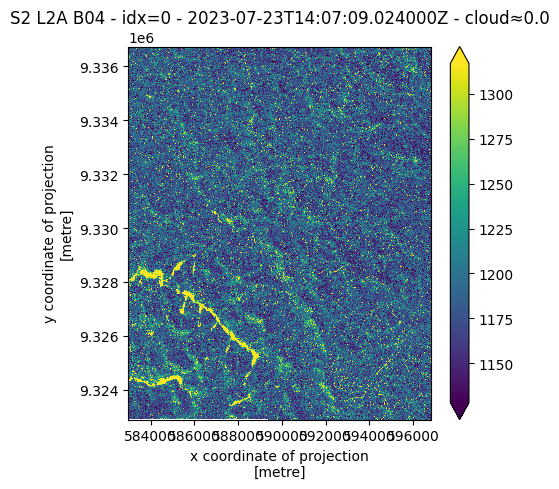

In [96]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import re
import tempfile
from pathlib import Path

import earthaccess as ea
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rxr
from shapely.geometry import shape

from pystac_client import Client
import planetary_computer as pc


# ======================================================================
# 1) AST_07XT – nuvem, ordenação, preview SWIR B04
# ======================================================================

def _extract_numbers_from_attr(attr):
    vals = attr.get("Values") or []
    text = " ".join(str(v) for v in vals)
    nums_str = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)
    if not nums_str:
        return None
    return [float(s) for s in nums_str]


def get_cloud_from_umm(granule):
    umm = granule["umm"]
    attrs = umm.get("AdditionalAttributes", [])
    best = None

    for attr in attrs:
        name = (attr.get("Name") or "").lower()
        if "cloud" not in name:
            continue
        nums = _extract_numbers_from_attr(attr)
        if not nums:
            continue
        mean_val = float(np.mean(nums))
        if best is None:
            best = (mean_val, nums, name)
        else:
            if "cloud_coverage_data" in name and "cloud_coverage_data" not in best[2]:
                best = (mean_val, nums, name)
            elif mean_val < best[0]:
                best = (mean_val, nums, name)

    if best is None:
        return None, None, None
    return best


def sort_by_cloud_ast(results):
    tmp = []
    for g in results:
        cc_mean, cc_list, attr_name = get_cloud_from_umm(g)
        if cc_mean is None:
            cc_mean = 999.0
            attr_name = None
        tmp.append((cc_mean, g, attr_name))
    tmp_sorted = sorted(tmp, key=lambda t: t[0])
    return tmp_sorted


def download_swir_b04(granule, out_dir=None):
    out_dir = Path(out_dir or tempfile.mkdtemp(prefix="AST_07XT_"))
    files = ea.download([granule], local_path=out_dir)
    b4_list = [Path(f) for f in files if "SRF_SWIR_B04" in str(f)]
    if not b4_list:
        raise RuntimeError("Nenhum arquivo SRF_SWIR_B04* encontrado nesse granule.")
    return b4_list[0]


def clip_to_geom(tif_path, geom_geojson):
    g = shape(geom_geojson)
    gdf = gpd.GeoDataFrame(geometry=[g], crs="EPSG:4326")
    da = rxr.open_rasterio(tif_path, masked=True)
    gdf_proj = gdf.to_crs(da.rio.crs)
    da_clip = da.rio.clip(
        gdf_proj.geometry,
        gdf_proj.crs,
        drop=True,
        all_touched=True,
    )
    return da_clip


def _get_granule_date_str(granule):
    umm = granule["umm"]
    te = umm.get("TemporalExtent") or umm.get("TemporalCoverage") or {}
    date = te.get("SingleDateTime")
    if not date:
        rd = te.get("RangeDateTime") or {}
        date = rd.get("BeginningDateTime") or "n/a"
    return date


def preview_swir_b04(granule, geom_geojson, out_dir=None, idx=None):
    tif_path = download_swir_b04(granule, out_dir=out_dir)
    da_clip = clip_to_geom(tif_path, geom_geojson)

    arr = da_clip.squeeze().values
    vmin, vmax = np.nanpercentile(arr, [2, 98])

    fig, ax = plt.subplots(figsize=(5, 5))
    da_clip.squeeze().plot.imshow(
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        yincrease=False,  # <-- evita o espelhamento vertical
    )

    date_str = _get_granule_date_str(granule)
    if idx is not None:
        title = f"AST_07XT SWIR B04 - idx={idx} - {date_str}"
    else:
        title = f"AST_07XT SWIR B04 - {date_str}"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return da_clip, tif_path


def search_ast07xt_for_geom(geom_geojson, temporal=("2000-01-01", "2015-01-01")):
    g = shape(geom_geojson)
    minx, miny, maxx, maxy = g.bounds

    ea.login()

    results = ea.search_data(
        short_name="AST_07XT",
        version="004",
        bounding_box=(minx, miny, maxx, maxy),
        temporal=temporal,
    )
    sorted_results = sort_by_cloud_ast(results)
    return results, sorted_results


# ======================================================================
# 2) Sentinel-2 L2A – nuvem, ordenação, preview B04
# ======================================================================

PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"


def search_s2_l2a_for_geom(
    geom_geojson,
    temporal=("2017-01-01", "2025-12-31"),
    cloud_max=60.0,
    limit=100,
):
    cat = Client.open(PC_STAC)
    dt = f"{temporal[0]}/{temporal[1]}"
    search = cat.search(
        collections=["sentinel-2-l2a"],
        intersects=geom_geojson,
        datetime=dt,
        query={"eo:cloud_cover": {"lt": cloud_max}},
        limit=limit,
    )
    items = list(search.get_items())
    items_sorted = sorted(
        items,
        key=lambda it: it.properties.get("eo:cloud_cover", 999.0),
    )
    return items, items_sorted


def _get_s2_datetime(item):
    return item.properties.get("datetime", "n/a")


def open_clip_s2_band(item, band, geom_geojson):
    pc.sign_inplace(item)
    href = item.assets[band].href
    da = rxr.open_rasterio(href, masked=True)
    g = shape(geom_geojson)
    gdf = gpd.GeoDataFrame(geometry=[g], crs="EPSG:4326")
    gdf_proj = gdf.to_crs(da.rio.crs)
    da_clip = da.rio.clip(
        gdf_proj.geometry,
        gdf_proj.crs,
        drop=True,
        all_touched=True,
    )
    return da_clip


def preview_s2_b04(item, geom_geojson, idx=None):
    da_clip = open_clip_s2_band(item, "B04", geom_geojson)

    arr = da_clip.squeeze().values
    vmin, vmax = np.nanpercentile(arr, [2, 98])

    fig, ax = plt.subplots(figsize=(5, 5))
    da_clip.squeeze().plot.imshow(ax=ax, vmin=vmin, vmax=vmax)

    dt = _get_s2_datetime(item)
    cc = item.properties.get("eo:cloud_cover", None)
    if idx is not None:
        title = f"S2 L2A B04 - idx={idx} - {dt} - cloud≈{cc}"
    else:
        title = f"S2 L2A B04 - {dt} - cloud≈{cc}"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return da_clip


# ======================================================================
# 3) Exemplo de uso para uma folha
# ======================================================================

if __name__ == "__main__":
    from db_conn import get_folha_geom_geojson as folha

    folha_id = "SB21_ZA_II2_NW"
    geom = folha(folha_id)

    # ---------------------- AST_07XT ----------------------
    results_ast, sorted_ast = search_ast07xt_for_geom(geom)
    print(f"Granules AST_07XT encontrados: {len(results_ast)}")

    N_ast = min(10, len(sorted_ast))
    for rank, (cc, gran, attr_name) in enumerate(sorted_ast[:N_ast]):
        date = _get_granule_date_str(gran)
        gran_id = gran["umm"].get("GranuleUR", "n/a")
        print(f"{rank:02d}  cloud≈{cc:5.1f}%  attr={attr_name}  date={date}  id={gran_id}")

    best_cc, best_gran, best_attr = sorted_ast[0]
    print("\nMelhor granule AST_07XT por nuvem:")
    print("cloud_mean≈", best_cc, "attr=", best_attr)
    da_ast, tif_ast = preview_swir_b04(best_gran, geom, idx=0)

    # ---------------------- Sentinel-2 L2A ----------------------
    items_s2, sorted_s2 = search_s2_l2a_for_geom(
        geom,
        temporal=("2017-01-01", "2025-12-31"),
        cloud_max=60.0,
        limit=100,
    )
    print(f"\nItens Sentinel-2 L2A encontrados: {len(items_s2)}")

    N_s2 = min(10, len(sorted_s2))
    for rank, it in enumerate(sorted_s2[:N_s2]):
        cc = it.properties.get("eo:cloud_cover", None)
        dt = _get_s2_datetime(it)
        print(f"{rank:02d}  cloud≈{cc:5.1f}%  datetime={dt}  id={it.id}")

    best_s2 = sorted_s2[0]
    print("\nMelhor cena S2 L2A por nuvem:")
    print("cloud≈", best_s2.properties.get("eo:cloud_cover", None),
          "datetime=", _get_s2_datetime(best_s2),
          "id=", best_s2.id)

    da_s2 = preview_s2_b04(best_s2, geom, idx=0)


In [ ]:
# from db_conn import get_folha_geom_geojson as folha

folha_id = "SB21_ZA_II1_NE"
geom = folha(folha_id)

# ---------------------- AST_07XT ----------------------
results_ast, sorted_ast = search_ast07xt_for_geom(geom)
print(f"Granules AST_07XT encontrados: {len(results_ast)}")

N_ast = min(10, len(sorted_ast))
for rank, (cc, gran, attr_name) in enumerate(sorted_ast[:N_ast]):
    date = _get_granule_date_str(gran)
    gran_id = gran["umm"].get("GranuleUR", "n/a")
    print(f"{rank:02d}  cloud≈{cc:5.1f}%  attr={attr_name}  date={date}  id={gran_id}")

best_cc, best_gran, best_attr = sorted_ast[0]
print("\nMelhor granule AST_07XT por nuvem:")
print("cloud_mean≈", best_cc, "attr=", best_attr)
da_ast, tif_ast = preview_swir_b04(best_gran, geom, idx=0)

# ---------------------- Sentinel-2 L2A ----------------------
items_s2, sorted_s2 = search_s2_l2a_for_geom(
    geom,
    temporal=("2017-01-01", "2017-12-31"),
    cloud_max=60.0,
    limit=100,
)
print(f"\nItens Sentinel-2 L2A encontrados: {len(items_s2)}")

N_s2 = min(10, len(sorted_s2))
for rank, it in enumerate(sorted_s2[:N_s2]):
    cc = it.properties.get("eo:cloud_cover", None)
    dt = _get_s2_datetime(it)
    print(f"{rank:02d}  cloud≈{cc:5.1f}%  datetime={dt}  id={it.id}")

best_s2 = sorted_s2[0]
print("\nMelhor cena S2 L2A por nuvem:")
print("cloud≈", best_s2.properties.get("eo:cloud_cover", None),
      "datetime=", _get_s2_datetime(best_s2),
      "id=", best_s2.id)

da_s2 = preview_s2_b04(best_s2, geom, idx=0)